In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv('1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

# Drop index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [2]:
# General information about columns and types
print("--- Data Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check shape
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 486.7+ KB

--- Missing Values ---
visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64

Dataset Shape: 5190 rows, 12 colu

In [3]:
# Statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00


In [4]:
# Categorical value distributions
cat_cols = ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

for col in cat_cols:
    print(f"--- {col.upper()} ---")
    print(df[col].value_counts(normalize=True) * 100)
    print()

--- GENDER ---
gender
female    52.061657
male      47.938343
Name: proportion, dtype: float64

--- PRIVATE ---
private
no     55.722543
yes    44.277457
Name: proportion, dtype: float64

--- FREEPOOR ---
freepoor
no     95.722543
yes     4.277457
Name: proportion, dtype: float64

--- FREEREPAT ---
freerepat
no     78.978805
yes    21.021195
Name: proportion, dtype: float64

--- NCHRONIC ---
nchronic
no     59.691715
yes    40.308285
Name: proportion, dtype: float64

--- LCHRONIC ---
lchronic
no     88.342967
yes    11.657033
Name: proportion, dtype: float64



/tmp/ipykernel_976/3990263324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='visits', ax=axes[0], palette='viridis')


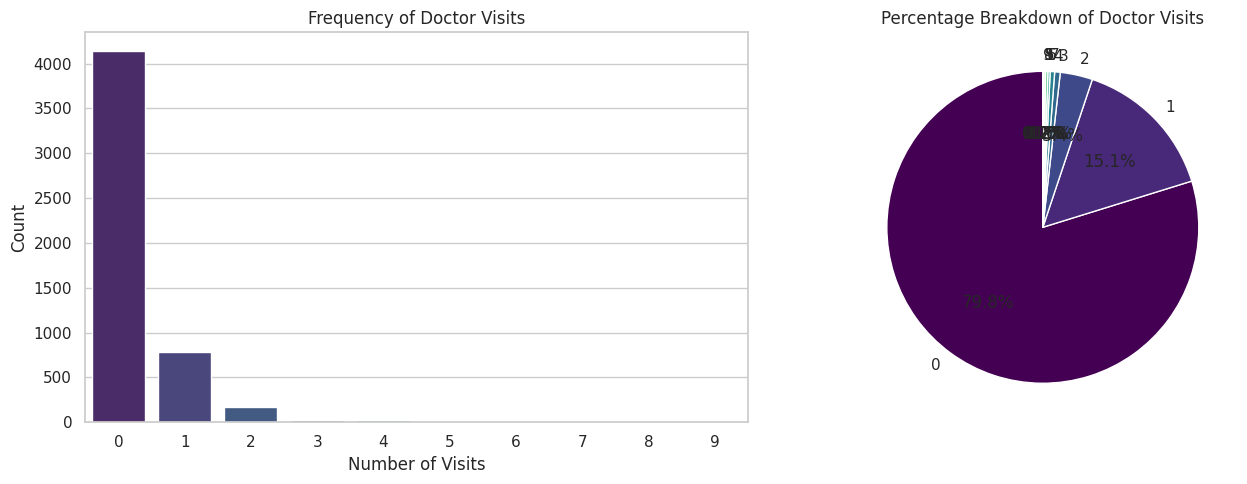

In [5]:
# Distribution of doctor visits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='visits', ax=axes[0], palette='viridis')
axes[0].set_title('Frequency of Doctor Visits')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Count')

# Percentage breakdown
visit_counts = df['visits'].value_counts(normalize=True) * 100
visit_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], startangle=90, cmap='viridis')
axes[1].set_title('Percentage Breakdown of Doctor Visits')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_976/961904224.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='gender', y='visits', ax=axes[0], ci=None, palette='Set2')
/tmp/ipykernel_976/961904224.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='gender', y='visits', ax=axes[0], ci=None, palette='Set2')


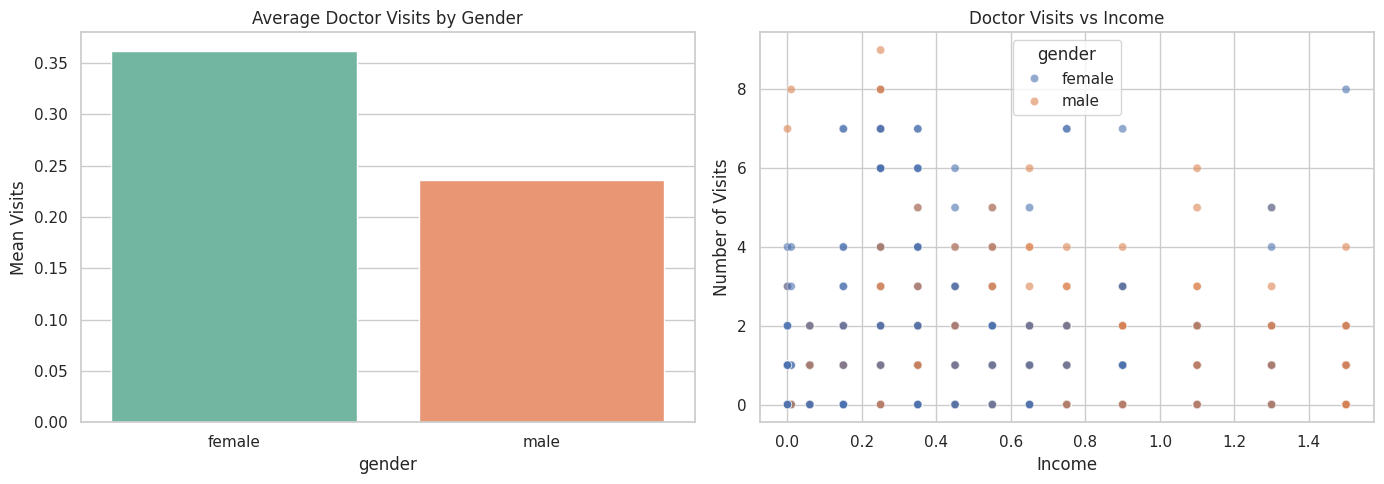

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visits by Gender
sns.barplot(data=df, x='gender', y='visits', ax=axes[0], ci=None, palette='Set2')
axes[0].set_title('Average Doctor Visits by Gender')
axes[0].set_ylabel('Mean Visits')

# Income vs Visits
sns.scatterplot(data=df, x='income', y='visits', hue='gender', alpha=0.6, ax=axes[1])
axes[1].set_title('Doctor Visits vs Income')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Number of Visits')

plt.tight_layout()
plt.show()

/tmp/ipykernel_976/3427167024.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='illness', y='visits', ax=axes[0], palette='Blues')


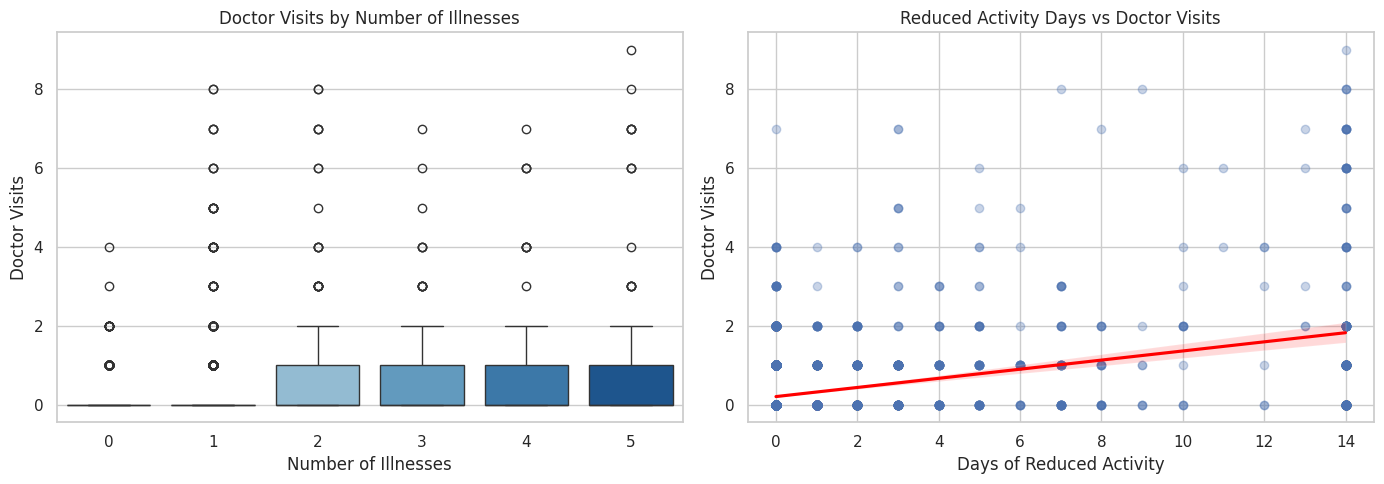

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Illness count vs Visits
sns.boxplot(data=df, x='illness', y='visits', ax=axes[0], palette='Blues')
axes[0].set_title('Doctor Visits by Number of Illnesses')
axes[0].set_xlabel('Number of Illnesses')
axes[0].set_ylabel('Doctor Visits')

# Reduced activity days vs Visits
sns.regplot(data=df, x='reduced', y='visits', ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title('Reduced Activity Days vs Doctor Visits')
axes[1].set_xlabel('Days of Reduced Activity')
axes[1].set_ylabel('Doctor Visits')

plt.tight_layout()
plt.show()

/tmp/ipykernel_976/1342506031.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=col, y='visits', ax=axes[i], palette='Pastel1', ci=None)
/tmp/ipykernel_976/1342506031.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='visits', ax=axes[i], palette='Pastel1', ci=None)
/tmp/ipykernel_976/1342506031.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=col, y='visits', ax=axes[i], palette='Pastel1', ci=None)
/tmp/ipykernel_976/1342506031.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='visits', ax=axes[i], pale

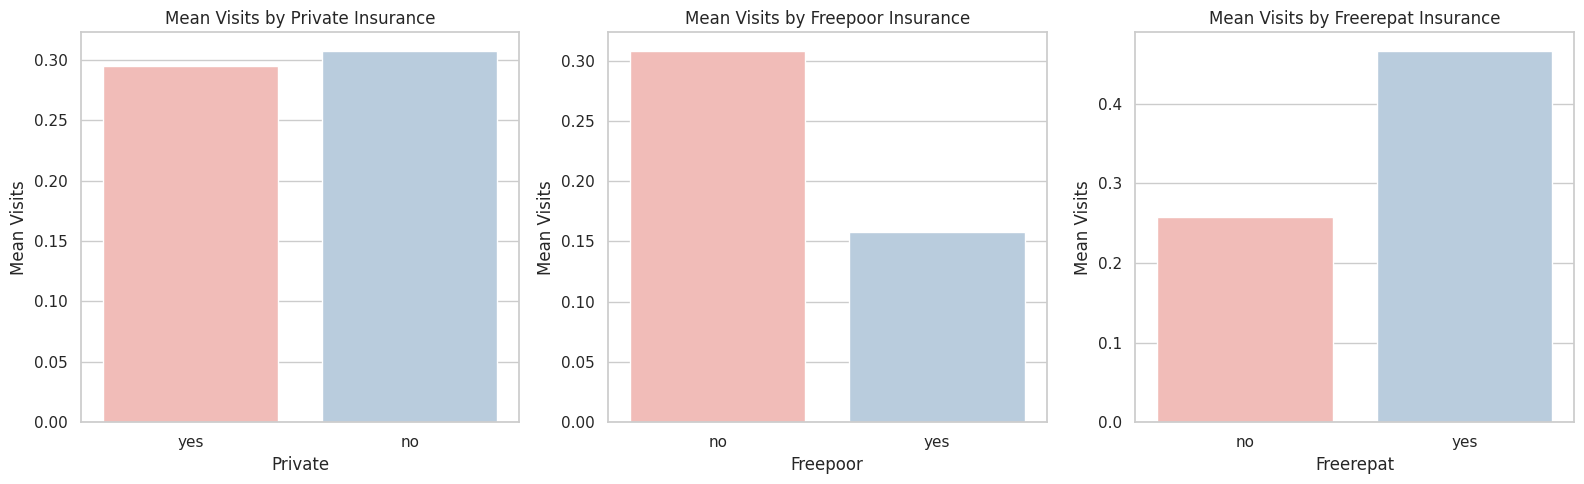

In [8]:
insurance_cols = ['private', 'freepoor', 'freerepat']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(insurance_cols):
    sns.barplot(data=df, x=col, y='visits', ax=axes[i], palette='Pastel1', ci=None)
    axes[i].set_title(f'Mean Visits by {col.capitalize()} Insurance')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Mean Visits')

plt.tight_layout()
plt.show()

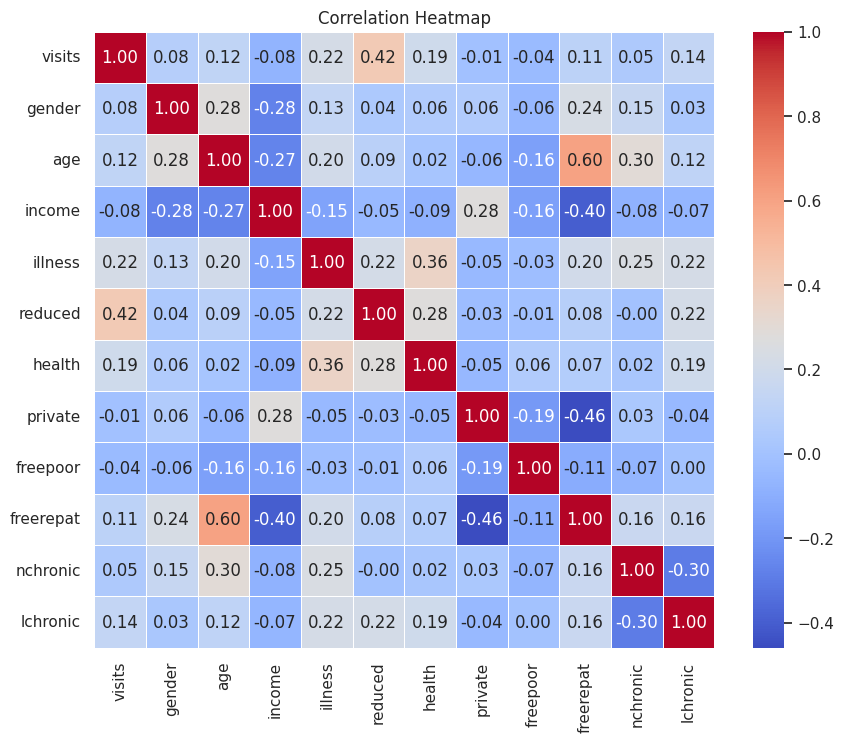

In [9]:
# Convert binary categorical columns to numeric for correlation mapping
df_numeric = df.copy()
binary_map = {'yes': 1, 'no': 0, 'female': 1, 'male': 0}

for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        df_numeric[col] = df_numeric[col].map(binary_map)

# Compute correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()